**Title:** Project Milestone Five for DSC630
**Author:** William Anderson  
**Date:** 20 May 2026  
**Description:** Milestone Five for DSC630

### Project Overview and Driving Question

This project focuses on predicting global video game sales using historical sales data, with the main goal being to determine whether global sales can be reasonably estimated from non-sales game attributes, specifically platform, genre, publisher, and release year. That wording is intentional because the dataset also includes regional sales fields, but those fields directly roll into global sales and would make the model look much stronger than it really is.

The driving question is: Can global video game sales be reasonably estimated using available non-sales attributes such as platform, genre, publisher, and release year? This question keeps the project focused on prediction rather than explanation, which is an important distinction for this dataset. The model may identify historical sales patterns, but it should not be treated as a complete explanation of why games succeed, especially since several important business factors are not present in the data.

### Load Libraries and Data
The code below loads the libraries used for the analysis and reads in the video game sales dataset. I kept the setup fairly direct here because the goal is to show the data preparation, modeling, evaluation, and interpretation clearly.

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

#display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

#load data from the same folder as this notebook - no hardcoded local filepath
DATA_PATH = Path("vgsales.csv")
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("OG dataset shape:", df.shape)
df.head(1)

Dataset loaded successfully.
Shape: (16598, 11)
Original dataset shape: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,"2,006.0000",Sports,Nintendo,41.4900,29.0200,3.7700,8.4600,82.7400
1,2,Super Mario Bros.,NES,"1,985.0000",Platform,Nintendo,29.0800,3.5800,6.8100,0.7700,40.2400
2,3,Mario Kart Wii,Wii,"2,008.0000",Racing,Nintendo,15.8500,12.8800,3.7900,3.3100,35.8200
3,4,Wii Sports Resort,Wii,"2,009.0000",Sports,Nintendo,15.7500,11.0100,3.2800,2.9600,33.0000
4,5,Pokemon Red/Pokemon Blue,GB,"1,996.0000",Role-Playing,Nintendo,11.2700,8.8900,10.2200,1.0000,31.3700


### Data Preparation Process
The preparation process is written as a modeling workflow instead of just an exploratory checkpoint. First, I checked the raw shape and missing values; next, I removed records missing release year or publisher because both fields are part of the planned predictor set. I also kept the 1980 through 2016 range used in the Kaggle source, which removed records that did not fit the historical scope of the analysis.

The most important preparation decision is that regional sales are excluded from the model; global sales is essentially built from North America sales, Europe sales, Japan sales, and other regional sales, so using those fields as predictors would introduce leakage. In simpler terms, the model would mostly be reconstructing the answer from pieces of the answer, which would not be an honest predictive test.

Publisher also needed additional handling since the dataset has hundreds of publishers, and many of them appear only a small number of times. To keep the model from being overloaded with sparse categories while avoiding minor leakage from the holdout set, publisher grouping is handled inside the modeling pipeline so the list of high-frequency publishers is learned from the training data only.

In [2]:
#check missing values before cleanup
missing_before = df.isna().sum().sort_values(ascending=False)
missing_before = missing_before[missing_before > 0].reset_index()
missing_before.columns = ["Field", "Missing Records"]
missing_before

,Field,Missing Records
0,Year,271
1,Publisher,58


### Does Removing Those Fields Materially Change the Data?
As mentioned, records with missing year or publisher values were removed because both fields are part of the planned predictor set - thankfully, this removal does not appear to materially distort the dataset, since it removes 311 records out of 16,598 total records, or about 1.87% of the data. After cleaning, the median global sales value remains unchanged at 0.17 million, the mean changes only slightly from 0.537 million to 0.541 million, and the dataset still retains all 31 platforms and all 12 genres. Because the removed records represent a small share of the dataset and do not meaningfully change the target distribution, removing them is a reasonable preprocessing decision for this project.

In [3]:
#check whether removing missing year/publisher rows materially changes the data

original_rows = len(df)

df_missing_removed = df.dropna(subset=["Year", "Publisher"]).copy()
df_missing_removed["Year"] = df_missing_removed["Year"].astype(int)

df_clean = df_missing_removed[
    (df_missing_removed["Year"] >= 1980) &
    (df_missing_removed["Year"] <= 2016)
].copy()

removed_rows = original_rows - len(df_clean)
removed_pct = removed_rows / original_rows * 100

impact_summary = pd.DataFrame({
    "Original Data": [
        len(df),
        df["Global_Sales"].mean(),
        df["Global_Sales"].median(),
        df["Global_Sales"].max(),
        df["Platform"].nunique(),
        df["Genre"].nunique(),
        df["Publisher"].nunique()
    ],
    "Cleaned Data": [
        len(df_clean),
        df_clean["Global_Sales"].mean(),
        df_clean["Global_Sales"].median(),
        df_clean["Global_Sales"].max(),
        df_clean["Platform"].nunique(),
        df_clean["Genre"].nunique(),
        df_clean["Publisher"].nunique()
    ]
}, index=[
    "Rows",
    "Mean Global Sales",
    "Median Global Sales",
    "Max Global Sales",
    "Unique Platforms",
    "Unique Genres",
    "Unique Publishers"
])

print(f"Rows removed: {removed_rows}")
print(f"Percent removed: {removed_pct:.2f}%")

impact_summary

Rows removed: 311
Percent removed: 1.87%


,Original Data,Cleaned Data
Rows,"16,598.0000","16,287.0000"
Mean Global Sales,0.5374,0.5410
Median Global Sales,0.1700,0.1700
Max Global Sales,82.7400,82.7400
Unique Platforms,31.0000,31.0000
Unique Genres,12.0000,12.0000
Unique Publishers,578.0000,576.0000


In [4]:
#drop rows that cannot support the planned predictors
df_clean = df.dropna(subset=["Year", "Publisher"]).copy()
df_clean["Year"] = df_clean["Year"].astype(int)

#keep the same historical range used in the Kaggle analysis
df_clean = df_clean[(df_clean["Year"] >= 1980) & (df_clean["Year"] <= 2016)].copy()

#custom transformer so publisher grouping is learned from the training data only
class PublisherGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_count=50):
        self.min_count = min_count

    def fit(self, X, y=None):
        publisher_counts = X["Publisher"].value_counts()
        self.top_publishers_ = publisher_counts[publisher_counts >= self.min_count].index
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out["Publisher_Grouped"] = np.where(
            X_out["Publisher"].isin(self.top_publishers_),
            X_out["Publisher"],
            "Other"
        )
        return X_out

#build modeling inputs before preprocessing
model_features = ["Platform", "Genre", "Publisher", "Year"]
target = "Global_Sales"

X = df_clean[model_features].copy()
y = df_clean[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#fit a temporary publisher grouper for summary reporting only
publisher_summary_grouper = PublisherGrouper(min_count=50).fit(X_train)
X_train_grouped_summary = publisher_summary_grouper.transform(X_train)

prep_summary = pd.DataFrame({
    "Preparation Item": [
        "Original dataset size",
        "Working dataset size",
        "Rows removed",
        "Missing year values in raw data",
        "Missing publisher values in raw data",
        "Platforms retained",
        "Genres retained",
        "Original publisher count",
        "Publisher groups learned from training data",
        "Training rows grouped as Other"
    ],
    "Result": [
        f"{df.shape[0]:,} records and {df.shape[1]} fields",
        f"{df_clean.shape[0]:,} records after cleanup",
        f"{removed_rows:,} records, or {removed_pct:.2f}%",
        int(df["Year"].isna().sum()),
        int(df["Publisher"].isna().sum()),
        int(df_clean["Platform"].nunique()),
        int(df_clean["Genre"].nunique()),
        int(df_clean["Publisher"].nunique()),
        int(X_train_grouped_summary["Publisher_Grouped"].nunique()),
        int((X_train_grouped_summary["Publisher_Grouped"] == "Other").sum())
    ]
})

prep_summary

,Preparation Item,Result
0,Original dataset size,"16,598 records and 11 fields"
1,Working dataset size,"16,287 records after cleanup"
2,Rows removed,"311 records, or 1.87%"
3,Missing year values in raw data,271
4,Missing publisher values in raw data,58
5,Platforms retained,31
6,Genres retained,12
7,Original publisher count,576
8,Publisher groups learned from training data,41
9,Training rows grouped as Other,2871


### Exploratory Analysis Evidence
The exploratory analysis still points to the same main issue: global sales is extremely right-skewed - most games have relatively low sales, while a small number of very large titles stretch the scale. That matters because the model may do reasonably well for ordinary games while still struggling with blockbuster outliers.

In [5]:
#summarize the target distribution
sales_summary = pd.DataFrame({
    "Metric": ["Mean", "Median", "Standard Dev", "Minimum", "75th Percentile", "90th Percentile", "95th Percentile", "99th Percentile", "Maximum", "Skewness"],
    "Global Sales in Millions": [
        df_clean["Global_Sales"].mean(),
        df_clean["Global_Sales"].median(),
        df_clean["Global_Sales"].std(),
        df_clean["Global_Sales"].min(),
        df_clean["Global_Sales"].quantile(0.75),
        df_clean["Global_Sales"].quantile(0.90),
        df_clean["Global_Sales"].quantile(0.95),
        df_clean["Global_Sales"].quantile(0.99),
        df_clean["Global_Sales"].max(),
        df_clean["Global_Sales"].skew()
    ]
})

sales_summary

,Metric,Global Sales in Millions
0,Mean,0.5410
1,Median,0.1700
2,Standard Dev,1.5675
3,Minimum,0.0100
4,75th Percentile,0.4800
5,90th Percentile,1.2200
6,95th Percentile,2.0500
7,99th Percentile,5.4728
8,Maximum,82.7400
9,Skewness,17.3026


In [6]:
#leakage check: regional sales nearly reconstruct global sales
df_clean["Regional_Total"] = (
    df_clean["NA_Sales"] +
    df_clean["EU_Sales"] +
    df_clean["JP_Sales"] +
    df_clean["Other_Sales"]
)

df_clean["Sales_Difference"] = df_clean["Global_Sales"] - df_clean["Regional_Total"]

leakage_summary = pd.DataFrame({
    "Leakage Check Item": [
        "Maximum absolute difference between global sales and regional total",
        "Mean absolute difference",
        "Median absolute difference"
    ],
    "Result": [
        df_clean["Sales_Difference"].abs().max(),
        df_clean["Sales_Difference"].abs().mean(),
        df_clean["Sales_Difference"].abs().median()
    ]
})

leakage_summary

,Leakage Check Item,Result
0,Maximum absolute difference between global sal...,0.0200
1,Mean absolute difference,0.0027
2,Median absolute difference,0.0000


### Visual Evidence
The visualizations below are included because they directly support the modeling decisions. 
The first chart shows why raw global sales is difficult to model cleanly: the values are heavily concentrated near the low end, while a few very high-selling games stretch the axis. 
Secondly, the log-transformed chart does not automatically mean the final model must use a transformed target, but it does show why a transformation is worth testing. 
Lastly, the platform and genre charts help explain the structure of the main predictors.

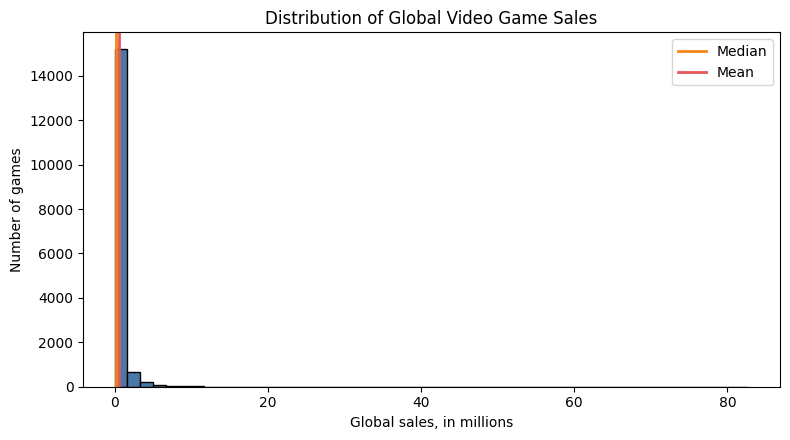

In [7]:
#figure 1: raw global sales distribution
plt.figure(figsize=(8, 4.5))
plt.hist(df_clean["Global_Sales"], bins=50, color="#4C78A8", edgecolor="black")
plt.axvline(df_clean["Global_Sales"].median(), color="#F58518", linewidth=2, label="Median")
plt.axvline(df_clean["Global_Sales"].mean(), color="#E45756", linewidth=2, label="Mean")
plt.title("Distribution of Global Video Game Sales")
plt.xlabel("Global sales, in millions")
plt.ylabel("Number of games")
plt.legend()
plt.tight_layout()
plt.show()

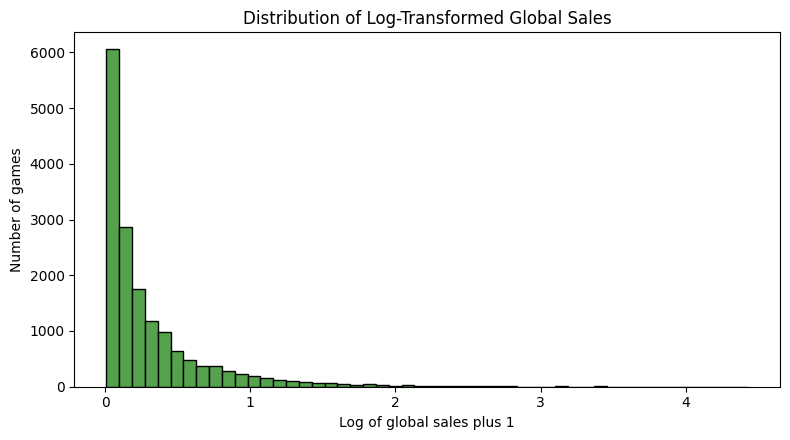

In [8]:
#figure 2: log-transformed global sales distribution
plt.figure(figsize=(8, 4.5))
plt.hist(np.log1p(df_clean["Global_Sales"]), bins=50, color="#54A24B", edgecolor="black")
plt.title("Distribution of Log-Transformed Global Sales")
plt.xlabel("Log of global sales plus 1")
plt.ylabel("Number of games")
plt.tight_layout()
plt.show()

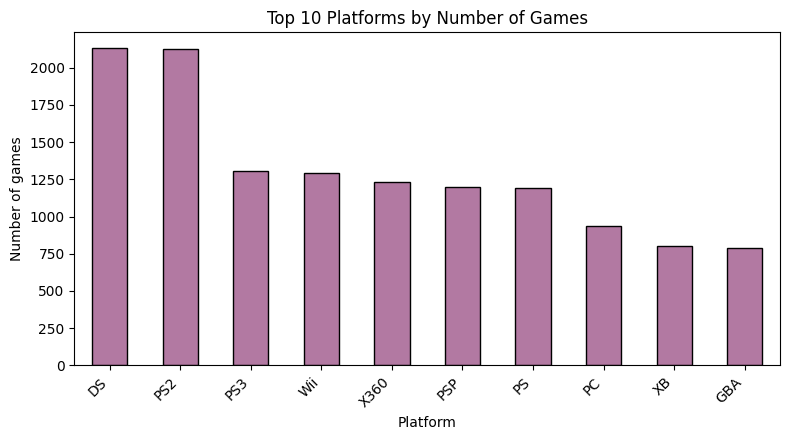

In [9]:
#figure 3: top platforms by count
top_platforms = df_clean["Platform"].value_counts().head(10)

plt.figure(figsize=(8, 4.5))
top_platforms.plot(kind="bar", color="#B279A2", edgecolor="black")
plt.title("Top 10 Platforms by Number of Games")
plt.xlabel("Platform")
plt.ylabel("Number of games")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

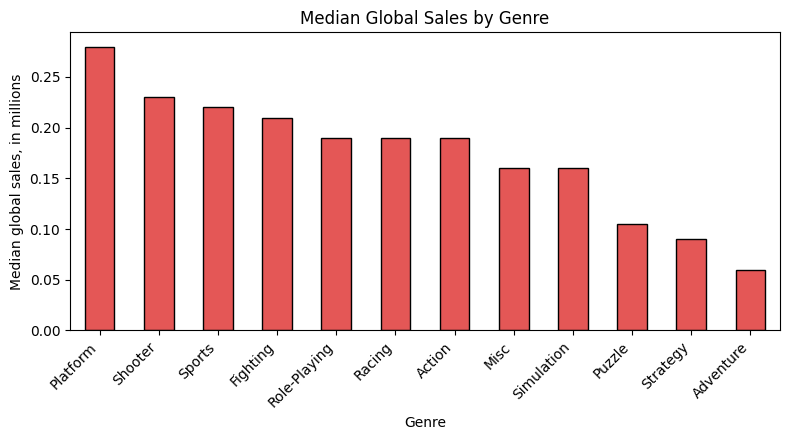

In [10]:
#figure 4: median global sales by genre
genre_median = df_clean.groupby("Genre")["Global_Sales"].median().sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
genre_median.plot(kind="bar", color="#E45756", edgecolor="black")
plt.title("Median Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Median global sales, in millions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Modeling Dataset Setup
For the actual model, I used platform, genre, publisher, and release year as predictorS - regional sales were intentionally left out because of the leakage issue - in addition to regional sales, game title and rank were also excluded because they are not useful general predictors for this version of the project.

The categorical variables were converted into numeric indicator variables inside the modeling pipeline. This matters because publisher grouping and one-hot encoding should be learned from the training data, not from the full dataset before the train-test split. That keeps the holdout set cleaner and avoids giving the model small amounts of information it should not have during training.

The data was split into training and testing sets using an 80/20 split. I used the training data to fit the models and the test data to evaluate how well the models performed on records they had not already seen; this makes the evaluation more meaningful than measuring performance only on the training data.

In [11]:
#build preprocessing pipeline

def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                make_encoder(),
                ["Platform", "Genre", "Publisher_Grouped"]
            ),
            (
                "numeric",
                "passthrough",
                ["Year"]
            )
        ],
        remainder="drop"
    )


def build_pipeline(model):
    return Pipeline(steps=[
        ("publisher_grouper", PublisherGrouper(min_count=50)),
        ("preprocess", build_preprocessor()),
        ("model", model)
    ])

modeling_summary = pd.DataFrame({
    "Modeling Item": [
        "Predictors used",
        "Predictors excluded for leakage",
        "Target",
        "Training records",
        "Testing records",
        "Preprocessing approach"
    ],
    "Result": [
        "Platform, genre, publisher, and release year",
        "Regional sales fields",
        "Global sales",
        X_train.shape[0],
        X_test.shape[0],
        "Publisher grouping and one-hot encoding fit on training data only"
    ]
})

modeling_summary

,Modeling Item,Result
0,Predictors used,"Platform, genre, publisher, and release year"
1,Predictors excluded for leakage,Regional sales fields
2,Target,Global sales
3,Training records,13029
4,Testing records,3258
5,Preprocessing approach,Publisher grouping and one-hot encoding fit on...


### Build and Evaluate Models
I evaluated several models so the final result would not depend on a single method, which could lead to potential issues, such as misleading conclusions. 
The mean baseline gives a simple reference point by predicting the average global sales value, linear regression and ridge regression provide straightforward baseline regression models, the decision tree and random forest models test whether nonlinear relationships and interactions improve performance and lastly, I also tested log-target versions because the sales distribution is so skewed.

The evaluation uses RMSE, MAE, and R-squared: RMSE is useful because it penalizes larger errors more heavily, which matters with blockbuster outliers - in addition to RMSE, MAE is also useful because it gives a more typical absolute error and is less dominated by extreme games. R-squared helps show how much variance the model explains, although with this dataset it should be interpreted carefully, as R-squared can look misleading, mainly due to two reasons: global sales is extremely right skewed and a small number of blockbuster titles can strongly influence this metric.

In [12]:
#define models
models = {
    "Mean Baseline": build_pipeline(DummyRegressor(strategy="mean")),
    "Linear Regression": build_pipeline(LinearRegression()),
    "Ridge Regression": build_pipeline(Ridge(alpha=10)),
    "Decision Tree": build_pipeline(
        DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42)
    ),
    "Random Forest": build_pipeline(
        RandomForestRegressor(
            n_estimators=50,
            max_depth=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    ),
    "Ridge Regression (Log Target)": TransformedTargetRegressor(
        regressor=build_pipeline(Ridge(alpha=10)),
        func=np.log1p,
        inverse_func=np.expm1
    ),
    "Random Forest (Log Target)": TransformedTargetRegressor(
        regressor=build_pipeline(
            RandomForestRegressor(
                n_estimators=50,
                max_depth=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        ),
        func=np.log1p,
        inverse_func=np.expm1
    )
}

#fit and evaluate models
model_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    predictions = np.maximum(predictions, 0)
    
    model_results.append({
        "Model": model_name,
        "Test RMSE": root_mean_squared_error(y_test, predictions),
        "Test MAE": mean_absolute_error(y_test, predictions),
        "Test R-squared": r2_score(y_test, predictions)
    })

results_df = pd.DataFrame(model_results).sort_values("Test RMSE").reset_index(drop=True)
results_df

,Model,Test RMSE,Test MAE,Test R-squared
0,Random Forest,1.9693,0.5243,0.0928
1,Linear Regression,1.9731,0.5452,0.0893
2,Ridge Regression,1.9736,0.5445,0.0888
3,Decision Tree,1.9762,0.5426,0.0864
4,Random Forest (Log Target),2.0088,0.4744,0.0560
5,Ridge Regression (Log Target),2.0088,0.4748,0.0560
6,Mean Baseline,2.0678,0.6187,-0.0003


In [13]:
#cross-validation check for the main comparison models
cv = KFold(n_splits=3, shuffle=True, random_state=42)
cv_models = {
    "Mean Baseline": models["Mean Baseline"],
    "Linear Regression": models["Linear Regression"],
    "Random Forest": models["Random Forest"],
    "Random Forest (Log Target)": models["Random Forest (Log Target)"]
}

cv_results = []
for model_name, model in cv_models.items():
    cv_scores = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1
    )
    
    cv_results.append({
        "Model": model_name,
        "CV RMSE Mean": cv_scores.mean(),
        "CV RMSE Std": cv_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV RMSE Mean").reset_index(drop=True)
cv_results_df

,Model,CV RMSE Mean,CV RMSE Std
0,Linear Regression,1.4527,0.2248
1,Random Forest (Log Target),1.4649,0.2362
2,Random Forest,1.4724,0.2005
3,Mean Baseline,1.5500,0.2337


### Model Results Interpretation
The model results show that the available predictors contain some useful signal, but not enough to make this a highly precise prediction problem. The random forest model had the lowest holdout test RMSE at about 1.97 million, compared with about 2.07 million for the mean baseline, but the improvement was modest. Its R-squared value was also only about 0.09, which means platform, genre, publisher, and release year explain only a small share of the variation in global sales.

The log-target models are also worth mentioning as they produced worse RMSE than the best raw-target random forest, but they had lower MAE. That means the log-target versions may do better for more typical games while performing worse on very large outliers. This is not necessarily a failure; it shows the tradeoff caused by the skewed sales distribution. If the goal is exact sales prediction for blockbuster titles, the raw model may be more appropriate. If the goal is a more stable model for typical games, the log-target approach may deserve more attention.

Finally, although the random forest model had the best holdout test RMSE, the cross-validation results were close enough that I would not treat it as a clearly dominant model: linear regression was close enough to remain a useful comparison point, which reinforces that the available predictors contain some signal, but not enough to make this a highly precise prediction problem.

### Feature Importance Review
To keep the interpretation at the right level, I reviewed grouped feature importance from the random forest model instead of only focusing on individual dummy variables. This gives a clearer view of which general groups are contributing most to the model. Feature importance should not be interpreted as causation, but it does help show what the model relied on most when making predictions.

In [14]:
#fit the selected model again for feature importance review
selected_model = models["Random Forest"]
selected_model.fit(X_train, y_train)

#extract feature names from the fitted preprocessing step
preprocess_step = selected_model.named_steps["preprocess"]
feature_names = preprocess_step.get_feature_names_out()

rf_model = selected_model.named_steps["model"]
feature_importance = pd.Series(rf_model.feature_importances_, index=feature_names)

grouped_importance = pd.Series({
    "Publisher": feature_importance[[c for c in feature_importance.index if "Publisher_Grouped" in c]].sum(),
    "Release year": feature_importance[[c for c in feature_importance.index if "Year" in c]].sum(),
    "Genre": feature_importance[[c for c in feature_importance.index if "Genre" in c]].sum(),
    "Platform": feature_importance[[c for c in feature_importance.index if "Platform" in c]].sum()
}).sort_values(ascending=False)

grouped_importance_df = grouped_importance.reset_index()
grouped_importance_df.columns = ["Feature Group", "Importance"]
grouped_importance_df

,Feature Group,Importance
0,Publisher,0.3564
1,Release year,0.3124
2,Genre,0.2050
3,Platform,0.1764


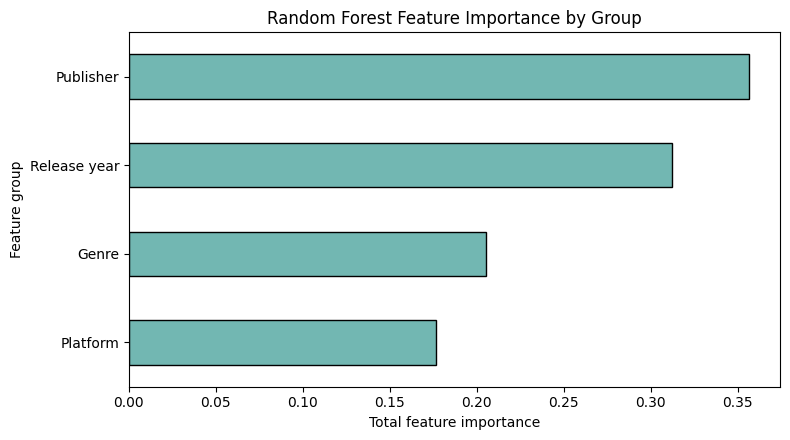

In [15]:
#figure 5: grouped feature importance
plt.figure(figsize=(8, 4.5))
grouped_importance.sort_values().plot(kind="barh", color="#72B7B2", edgecolor="black")
plt.title("Random Forest Feature Importance by Group")
plt.xlabel("Total feature importance")
plt.ylabel("Feature group")
plt.tight_layout()
plt.show()

### Actual vs. Predicted Review Using the Best Model
After reviewing feature importance, I wanted to connect the model results back to actual games in the test set, since that was essentially the whole point/discussion topic around this project. The evaluation table showed which model performed best overall, but an actual-versus-predicted review makes the results easier to interpret in plain English. For this section, I used the best-performing model based on test RMSE and compared its predicted global sales against the actual global sales values for games it had not seen during training.

In [16]:
#identify the best model from the model results table
best_model_name = results_df.sort_values("Test RMSE").iloc[0]["Model"]
best_model = models[best_model_name]

#fit the best model again on the training data
best_model.fit(X_train, y_train)

#generate predictions on the test set
best_predictions = best_model.predict(X_test)
best_predictions = np.maximum(best_predictions, 0)

print("Model selected:", best_model_name)

Model selected: Random Forest


In [17]:
#build actual vs predicted game-level comparison table

prediction_review = df_clean.loc[X_test.index, [
    "Name",
    "Platform",
    "Genre",
    "Publisher",
    "Year",
    "Global_Sales"
]].copy()

prediction_review["Predicted_Global_Sales"] = best_predictions
prediction_review["Prediction_Error"] = (
    prediction_review["Predicted_Global_Sales"] - prediction_review["Global_Sales"]
)
prediction_review["Absolute_Error"] = prediction_review["Prediction_Error"].abs()

prediction_review = prediction_review.rename(columns={
    "Name": "Game",
    "Global_Sales": "Actual Global Sales"
})

prediction_review[[
    "Game",
    "Platform",
    "Genre",
    "Publisher",
    "Year",
    "Actual Global Sales",
    "Predicted_Global_Sales",
    "Prediction_Error",
    "Absolute_Error"
]].head(5)

,Game,Platform,Genre,Publisher,Year,Actual Global Sales,Predicted_Global_Sales,Prediction_Error,Absolute_Error
2366,Star Wars: Rebel Assault II - The Hidden Empire,PS,Shooter,CTO SpA,1996,0.8800,0.3653,-0.5147,0.5147
12494,Neon Genesis Evangelion,N64,Adventure,Namco Bandai Games,1999,0.0600,0.4275,0.3675,0.3675
123,Red Dead Redemption,PS3,Action,Take-Two Interactive,2010,6.6000,3.8940,-2.7060,2.7060
14178,Nobunaga's Ambition: Sphere of Influence - Sen...,PS3,Misc,Tecmo Koei,2016,0.0300,0.3378,0.3078,0.3078
7334,Backyard NFL Football '09,Wii,Sports,Atari,2008,0.2100,0.3602,0.1502,0.1502


In [18]:
#review the highest-selling games in the test set

highest_actual_sales = prediction_review.sort_values(
    "Actual Global Sales",
    ascending=False
).head(5)

highest_actual_sales[[
    "Game",
    "Platform",
    "Genre",
    "Publisher",
    "Year",
    "Actual Global Sales",
    "Predicted_Global_Sales",
    "Prediction_Error",
    "Absolute_Error"
]]

,Game,Platform,Genre,Publisher,Year,Actual Global Sales,Predicted_Global_Sales,Prediction_Error,Absolute_Error
0,Wii Sports,Wii,Sports,Nintendo,2006,82.7400,4.1414,-78.5986,78.5986
3,Wii Sports Resort,Wii,Sports,Nintendo,2009,33.0000,1.2260,-31.7740,31.7740
8,New Super Mario Bros. Wii,Wii,Platform,Nintendo,2009,28.6200,3.3152,-25.3048,25.3048
14,Wii Fit Plus,Wii,Sports,Nintendo,2009,22.0000,1.2260,-20.7740,20.7740
15,Kinect Adventures!,X360,Misc,Microsoft Game Studios,2010,21.8200,1.8966,-19.9234,19.9234


In [19]:
#review the largest prediction misses from the best model

largest_prediction_errors = prediction_review.sort_values(
    "Absolute_Error",
    ascending=False
).head(5)

largest_prediction_errors[[
    "Game",
    "Platform",
    "Genre",
    "Publisher",
    "Year",
    "Actual Global Sales",
    "Predicted_Global_Sales",
    "Prediction_Error",
    "Absolute_Error"
]]

,Game,Platform,Genre,Publisher,Year,Actual Global Sales,Predicted_Global_Sales,Prediction_Error,Absolute_Error
0,Wii Sports,Wii,Sports,Nintendo,2006,82.7400,4.1414,-78.5986,78.5986
3,Wii Sports Resort,Wii,Sports,Nintendo,2009,33.0000,1.2260,-31.7740,31.7740
8,New Super Mario Bros. Wii,Wii,Platform,Nintendo,2009,28.6200,3.3152,-25.3048,25.3048
14,Wii Fit Plus,Wii,Sports,Nintendo,2009,22.0000,1.2260,-20.7740,20.7740
15,Kinect Adventures!,X360,Misc,Microsoft Game Studios,2010,21.8200,1.8966,-19.9234,19.9234


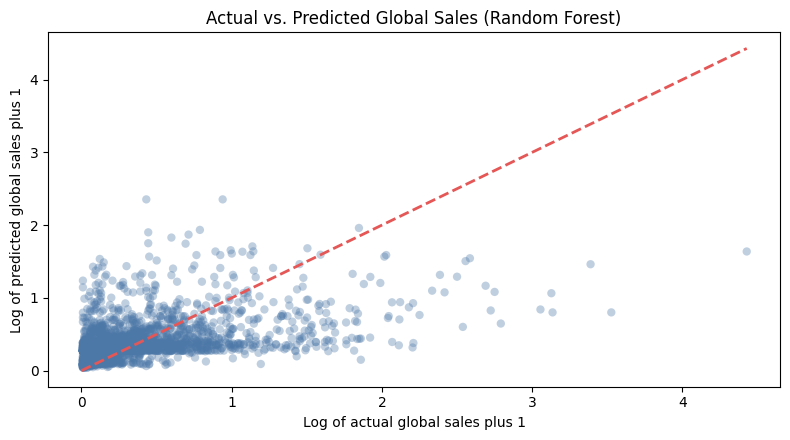

In [20]:
#figure 6: actual vs predicted global sales using the best model

plt.figure(figsize=(8, 4.5))
plt.scatter(
    np.log1p(prediction_review["Actual Global Sales"]),
    np.log1p(prediction_review["Predicted_Global_Sales"]),
    alpha=0.35,
    color="#4C78A8",
    edgecolor="none"
)

max_value = max(
    np.log1p(prediction_review["Actual Global Sales"]).max(),
    np.log1p(prediction_review["Predicted_Global_Sales"]).max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    color="#E45756",
    linestyle="--",
    linewidth=2
)

plt.title(f"Actual vs. Predicted Global Sales ({best_model_name})")
plt.xlabel("Log of actual global sales plus 1")
plt.ylabel("Log of predicted global sales plus 1")
plt.tight_layout()
plt.show()

The actual-versus-predicted review shows the practical limitation of the model more clearly than the metrics alone - even though the selected model performed best by test RMSE, it still struggles with individual game-level prediction, especially for games that sell far above the typical title. This fits the earlier EDA, since global sales are extremely right-skewed and the dataset does not include several major drivers of commercial success, such as marketing spend, review scores, franchise strength, release timing, or bundled distribution. Wii Sports is the clearest example of this limitation, since its sales were heavily tied to the Wii hardware ecosystem and bundling rather than only the normal game-level attributes available in the dataset. The same broader issue appears with several other high-selling titles in the error table, where franchise strength, hardware adoption, marketing, or bundled distribution likely played a major role. Because those factors are not included in the data, the model tends to pull these games closer to normal platform, genre, publisher, and year patterns, which leads to underprediction for extreme sales outcomes. For that reason, the selected model is better interpreted as a historical pattern model rather than a precise forecasting tool for individual releases.

### Sensitivity Analysis: Typical Games Versus Blockbuster Outliers
Because the largest prediction errors were tied to extreme high-selling games, I also added a sensitivity analysis that removes the most extreme blockbuster records. The cutoff was learned from the training data only by using the 99th percentile of global sales in the training set. The random forest model was then retrained on the typical-game training records and evaluated on the matching typical-game holdout records.

This is not meant to hide the outliers - rather, it helps separate two questions: how the model performs on the full dataset, including blockbuster games, and how it performs on more typical historical releases.

In [21]:
#sensitivity analysis: remove extreme blockbuster records using training-data cutoff
blockbuster_cutoff = y_train.quantile(0.99)

typical_train_mask = y_train <= blockbuster_cutoff
typical_test_mask = y_test <= blockbuster_cutoff

X_train_typical = X_train.loc[typical_train_mask]
y_train_typical = y_train.loc[typical_train_mask]

X_test_typical = X_test.loc[typical_test_mask]
y_test_typical = y_test.loc[typical_test_mask]

typical_model = build_pipeline(
    RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
)

typical_model.fit(X_train_typical, y_train_typical)
typical_predictions = typical_model.predict(X_test_typical)
typical_predictions = np.maximum(typical_predictions, 0)

full_rf_metrics = results_df[results_df["Model"] == "Random Forest"].iloc[0]

sensitivity_summary = pd.DataFrame({
    "Scenario": [
        "Full holdout test set",
        "Typical-game sensitivity set"
    ],
    "Test Records": [
        len(y_test),
        len(y_test_typical)
    ],
    "Test RMSE": [
        full_rf_metrics["Test RMSE"],
        root_mean_squared_error(y_test_typical, typical_predictions)
    ],
    "Test MAE": [
        full_rf_metrics["Test MAE"],
        mean_absolute_error(y_test_typical, typical_predictions)
    ],
    "Test R-squared": [
        full_rf_metrics["Test R-squared"],
        r2_score(y_test_typical, typical_predictions)
    ]
})

print(f"Blockbuster cutoff learned from training data: {blockbuster_cutoff:.4f} million")
print(f"Extreme holdout records removed: {len(y_test) - len(y_test_typical)}")
sensitivity_summary

Blockbuster cutoff learned from training data: 5.4444 million
Extreme holdout records removed: 35


,Scenario,Test Records,Test RMSE,Test MAE,Test R-squared
0,Full holdout test set,3258,1.9693,0.5243,0.0928
1,Typical-game sensitivity set,3223,0.6677,0.3638,0.1453


The sensitivity analysis shows that the model performs much better once the most extreme blockbuster records are removed from the evaluation set. That supports the main interpretation of the project: the model is more useful for identifying broad historical patterns among ordinary games than it is for precisely forecasting unusually high-selling releases.

### Final Conclusions and Recommendations

The main conclusion is that the project is technically workable, but the results need to be framed carefully. The model improves over a mean baseline, which shows that the available non-sales attributes have some predictive value. However, the improvement is modest, and the low R-squared value shows that much of video game success remains unexplained by the current dataset.

The final recommendation is to present the model as a historical pattern-recognition tool rather than a precise forecasting system. Platform, genre, publisher, and release year can provide some signal, but any serious prediction of individual game success would need additional context. Useful additions would include critic scores, user ratings, franchise indicators, marketing budget, development budget, digital sales context, and whether a game was bundled with hardware.

Overall, this analysis should not claim that the model can precisely predict future releases. A better and more defensible conclusion is that historical game attributes provide some predictive signal, while major modern releases depend on business, cultural, and market factors that are not captured in the current dataset. Some of that gap may simply come from factors the dataset cannot measure, such as timing, cultural momentum, player reception, and the harder-to-define “developer magic” that separates a normal release from a breakout hit.

### Risks, Limitations, and Ethical Considerations

The main/primary ethical risk is overinterpretation - the model can show associations between game attributes and sales, but those relationships should not be treated as proof of causation. Publisher, genre, platform, and year may also reflect missing factors such as marketing strength, franchise history, release timing, and brand recognition.

The leakage issue also remains important, as excluding regional sales makes the model weaker numerically, but it makes the analysis more honest because the model is not reconstructing global sales from its component pieces.

### References
Upadorprofzs. (n.d.). *EDA video game sales*. Kaggle. https://www.kaggle.com/code/upadorprofzs/eda-video-game-sales